# 06_prebuilt_react

对应 `index.md` 第 6 阶段：`ToolNode`、`tools_condition`、预置 ReAct agent、手写图 vs 预置。

笔记本在 `codes/langgraph/06_prebuilt_react/qa.ipynb`。需要读写文件时，工作空间就是这个目录。

先运行下一格，得到 `ROOT` 并加载 `codes/langgraph/local.env`。每题只改 `# 作答` 下面的代码。前置代码不用改。做完自己跑通即可，先不要对答案。

第 2 阶段你手写了 ReAct 全套：`should_continue` 路由、`run_tools` 节点里逐条 `ToolMessage(...)`。这些东西每个 Agent 都要写一遍，于是 LangGraph 把它们做成了现成的零件：

| 零件 | 取代了 |
| --- | --- |
| `ToolNode(tools)` | 你的 `run_tools` 节点 |
| `tools_condition` | 你的 `should_continue` |
| `create_agent(model, tools)` | 整张图 |

**注意版本**：网上常见的 `create_react_agent`（在 `langgraph.prebuilt` 里）在当前版本已弃用，会提示改用 `langchain.agents.create_agent`。两者建出来的图节点名不同（`agent` vs `model`），后面有一题会让你看到。

预置不等于黑盒：建出来的还是那张 `agent ↔ tools` 的图，一样能 `stream`、接 checkpointer、下断点，只是接线别人替你干了。第 1 题起都要调 API。


In [1]:
import os
from pathlib import Path

def lab_root() -> Path:
    """qa.ipynb 所在目录。"""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        if folder.name == "06_prebuilt_react" and (folder / "qa.ipynb").is_file():
            return folder
        candidate = folder / "codes" / "langgraph" / "06_prebuilt_react"
        if (candidate / "qa.ipynb").is_file():
            return candidate
    return here

def load_local_env(env_path: Path) -> None:
    """把 local.env 写入 os.environ（已有键不覆盖）。"""
    if not env_path.is_file():
        return
    for raw in env_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key = key.strip()
        value = value.strip().strip("\"'")
        if key and key not in os.environ:
            os.environ[key] = value

ROOT = lab_root()
load_local_env(ROOT.parent / "local.env")
ROOT, bool(os.environ.get("DEEPSEEK_API_KEY"))


(PosixPath('/Users/keyficller/Documents/AEFS-Notes/codes/langgraph/06_prebuilt_react'),
 True)

## 1. `ToolNode`：把 `run_tools` 那一段删掉

`ToolNode(tools)` 是个现成节点：它读 state 最后一条 `AIMessage` 的 `tool_calls`，逐个执行，把结果包成 `ToolMessage` 写回 `messages`。你在第 2 阶段手写的那十几行（取 `call["id"]`、`.invoke(call["args"])`、构造 `ToolMessage`）它全包了。它的默认节点名就叫 `tools`。

已有 `model`、工具 `add` / `mul`、`bound = model.bind_tools(tools)`、节点函数 `agent` 与 `should_continue`，以及只注册了 `agent` 的 `graph`（还没连任何边）。

1. `from langgraph.prebuilt import ToolNode`，加一个节点：`graph.add_node("tools", ToolNode(tools))`
2. 连边：`START → agent`；`agent` 挂条件边 `add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})`；`tools → agent`
3. `compile` 后 `invoke({"messages": [HumanMessage("先算 12 加 30，再把结果乘以 2。")]})`
4. 打印消息条数，并逐条打印 `type(m).__name__` 与该条的 `content` / `tool_calls`

预期 6 条：Human → AI(调用 add) → Tool(42) → AI(调用 mul) → Tool(84) → AI(总结)。条件边仍是你第 2 阶段那个 `should_continue`——这题只换执行工具的那一段。


In [6]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

@tool
def add(a: int, b: int) -> int:
    """两数相加。"""
    return a + b

@tool
def mul(a: int, b: int) -> int:
    """两数相乘。"""
    return a * b

tools = [add, mul]
bound = model.bind_tools(tools)

def agent(state: MessagesState) -> dict:
    return {"messages": [bound.invoke(state["messages"])]}

def should_continue(state: MessagesState) -> str:
    return "tools" if state["messages"][-1].tool_calls else END

graph = StateGraph(MessagesState)
graph.add_node("agent", agent)

# 作答

from langgraph.prebuilt import ToolNode

graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "agent")
graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

graph.add_edge("tools", "agent")

app = graph.compile()

result = app.invoke({"messages": [HumanMessage("先算 12 加 30，再把结果乘以 2。")]})

print(len(result["messages"]))

for msg in result["messages"]:
    msg.pretty_print()
#评阅
# 对。6 条消息、ToolNode 挂成 "tools" 节点、条件边仍用你自己写的 should_continue，和你第 2 阶段那版结构一致，
# 只是执行工具那十几行换成了 ToolNode。
# 你改用 msg.pretty_print() 而不是 type(m).__name__：信息其实更多（块头、Tool Calls 都列出来了），
# 不过标题是"Ai Message"这种给人看的写法，不是类名 HumanMessage / AIMessage；要按类名判断的场合还是用
# type(m).__name__。
# 小点：path_map 里的 {END: END} 等价于 {"__end__": "__end__"}，因为 END 本身就是字符串 "__end__"。写 END 更清楚。

#参考答案
# from langgraph.prebuilt import ToolNode
#
# graph.add_node("tools", ToolNode(tools))
# graph.add_edge(START, "agent")
# graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
# graph.add_edge("tools", "agent")
# app = graph.compile()
#
# result = app.invoke({"messages": [HumanMessage("先算 12 加 30，再把结果乘以 2。")]})
# print(len(result["messages"]))          # 6
# for m in result["messages"]:
#     print(type(m).__name__, getattr(m, "tool_calls", None) or m.content)



6
================================ Human Message =================================

先算 12 加 30，再把结果乘以 2。
================================== Ai Message ==================================
Tool Calls:
  add (call_00_RF5Sc6dc6jGZ4Mi1xb8Y2636)
 Call ID: call_00_RF5Sc6dc6jGZ4Mi1xb8Y2636
  Args:
    a: 12
    b: 30
================================= Tool Message =================================
Name: add

42
================================== Ai Message ==================================
Tool Calls:
  mul (call_00_BCmlD3Q5O8PjqXzVqUmc9934)
 Call ID: call_00_BCmlD3Q5O8PjqXzVqUmc9934
  Args:
    a: 42
    b: 2
================================= Tool Message =================================
Name: mul

84
================================== Ai Message ==================================

先算：12 + 30 = 42  
再算：42 × 2 = 84  

结果是 **84**。


## 2. `tools_condition`：连路由函数也不用写了

`tools_condition` 就是官方的 `should_continue`：最后一条 `AIMessage` 有 `tool_calls` 就返回 `"tools"`，否则返回 `END`（值是字符串 `"__end__"`）。

已有和第 1 题相同的前置代码（`add` / `mul` / `bound` / `agent` / `should_continue`）。

1. 直接调用它，打印两种输入下的返回值：
   - `tools_condition({"messages": [HumanMessage("你好")]})`
   - `tools_condition({"messages": [AIMessage("", tool_calls=[{"name": "add", "args": {"a": 1, "b": 2}, "id": "c1"}])]})`
   （记得 `from langchain_core.messages import AIMessage`）
2. 打印 `END` 的**实际值**，确认它和上一步的某个返回值相等
3. 重建图：`agent` + `ToolNode(tools)`，走到 `agent` 的条件边时用 `add_conditional_edges("agent", tools_condition)`——**不传 path_map**
4. `invoke` 同样的问题（`"先算 12 加 30，再把结果乘以 2。"`），打印最终 `content` 和消息条数

第 3 步能省掉 path_map，是因为它返回的字符串正好是节点名和 `END`。这也是它比自定义 router 脆的地方：你的 `tools` 节点必须就叫 `tools`。


In [11]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import tools_condition

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

@tool
def add(a: int, b: int) -> int:
    """两数相加。"""
    return a + b

@tool
def mul(a: int, b: int) -> int:
    """两数相乘。"""
    return a * b

tools = [add, mul]
bound = model.bind_tools(tools)

def agent(state: MessagesState) -> dict:
    return {"messages": [bound.invoke(state["messages"])]}

def should_continue(state: MessagesState) -> str:
    return "tools" if state["messages"][-1].tool_calls else END

from langchain_core.messages import AIMessage

# 作答

print(tools_condition({"messages": [HumanMessage("你好")]}))

print(tools_condition({"messages": [AIMessage("", tool_calls=[{"name": "add", "args": {"a": 1, "b": 2}, "id": "c1"}])]}))

print(END)

graph = StateGraph(MessagesState)

graph.add_node("agent", agent)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "agent")

graph.add_conditional_edges("agent", tools_condition)

graph.add_edge("tools", "agent")

app = graph.compile()

result = app.invoke({"messages": [HumanMessage("先算 12 加 30，再把结果乘以 2。")]})

print(len(result["messages"]))
result["messages"][-1].pretty_print()
#评阅
# 对。三种返回都核对上了：无 tool_calls → __end__，有 tool_calls → tools，END 的值就是 "__end__"；
# 不传 path_map 的图同样 6 条消息跑通。专门把 END 打出来和返回值对照，这一步做得好。
# 一个隐患：这一格用了 ToolNode，但 import 里只有 tools_condition——它能跑，是因为第 1 题那格已经把 ToolNode
# 导进同一个内核命名空间了。重启内核后单独跑这题就会 NameError。改成
# `from langgraph.prebuilt import ToolNode, tools_condition` 更稳。

#参考答案
# from langgraph.prebuilt import ToolNode, tools_condition
#
# print(tools_condition({"messages": [HumanMessage("你好")]}))              # __end__
# print(tools_condition({"messages": [AIMessage("", tool_calls=[{"name": "add", "args": {"a": 1, "b": 2}, "id": "c1"}])]}))  # tools
# print(repr(END))                                                        # '__end__'
#
# g = StateGraph(MessagesState)
# g.add_node("agent", agent)
# g.add_node("tools", ToolNode(tools))
# g.add_edge(START, "agent")
# g.add_conditional_edges("agent", tools_condition)      # 不传 path_map
# g.add_edge("tools", "agent")
# r = g.compile().invoke({"messages": [HumanMessage("先算 12 加 30，再把结果乘以 2。")]})
# print(len(r["messages"]))                              # 6




__end__
tools
__end__
6
================================== Ai Message ==================================

结果：

1. 12 + 30 = **42**
2. 42 × 2 = **84**

最终答案是 **84**。


## 3. 工具报错时 `ToolNode` 怎么办

工具跑挂了，是让异常冒泡把整个图炸掉，还是把它变成一条 `ToolMessage` 交回给模型，让模型自己看着办？`ToolNode` 的 `handle_tool_errors` 决定这件事——但它的**默认值容错范围比多数人以为的小**。

已有 `model`、会抛错的工具 `boom`、`call`（一条带 `boom` 调用的 `AIMessage`），以及辅助函数 `tools_only_app(node)`：它把传进来的 ToolNode 单独连成 `START → tools → END` 的小图，不经过模型，跑得快也稳定。

1. `app_default = tools_only_app(ToolNode([boom]))`，`invoke({"messages": [HumanMessage("go"), call]})`，用 `try/except` 接住异常，打印异常类型与消息
2. `app_soft = tools_only_app(ToolNode([boom], handle_tool_errors=True))`，同样 `invoke`，打印最后一条消息的类型、`content`、`status`

**第 3、4 步是本题重点：这回让工具名根本不存在，看默认行为还灵不灵。**

3. 先造第三条消息，让「模型」请求调用一个**没注册过的**工具：
   - 工具名写 `"nope"`（`ToolNode([boom])` 里只有 `boom`，没有 `nope`）
   - `args` 随便给（比如 `{}`）；`id` 用 `"c2"`，免得和第 1 步的 `"c1"` 撞
   - 也就是 `call_unknown = AIMessage("", tool_calls=[{"name": "nope", "args": {}, "id": "c2"}])`

   然后**复用第 1 步那个 `app_default`**——不用新建图，也不用再建一遍 `ToolNode`——直接
   `app_default.invoke({"messages": [HumanMessage("go"), call_unknown]})`。
   这回**不要写 `try/except`**，就让它自然跑；跑完打印最后一条消息的 `type(...).__name__`、`content`、`status`。

4. 把第 1 步和第 3 步并排看：同一个 `app_default`、同样「这一步没法正常执行」，一次异常冒到 `except`，
   一次却安静地返回了一条消息。`ToolNode` 是拿什么标准把这两种情况分开的？
   去读一眼 `ToolNode` 默认用的那个 `handle_tool_errors`（源码里叫 `_default_handle_tool_errors`），
   再对一下两步里抛出的异常**类型**有什么不同。

提示：默认容错只覆盖**一类**错误，不是「所有工具异常都变消息」。想让 `boom` 那种来自工具函数体的异常也被吞掉，就得自己给 `handle_tool_errors` 传 `True`、一个提示字符串或一个 `Callable`——第 2 步正是这么做的。


In [21]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

@tool
def boom(x: int) -> int:
    """计算 x 的两倍；x 为 1 时故意抛错。"""
    if x == 1:
        raise ValueError("炸了")
    return x * 2

def tools_only_app(node: ToolNode):
    """把 ToolNode 单独连成 START → tools → END 的小图，不调模型。"""
    g = StateGraph(MessagesState)
    g.add_node("tools", node)
    g.add_edge(START, "tools")
    g.add_edge("tools", END)
    return g.compile()

call = AIMessage("", tool_calls=[{"name": "boom", "args": {"x": 1}, "id": "c1"}])

# 作答

app_default = tools_only_app(ToolNode([boom]))

try:
    result = app_default.invoke({"messages": [HumanMessage("go"), call]})
except Exception as e:
    print(type(e).__name__, str(e))

app_soft = tools_only_app(ToolNode([boom], handle_tool_errors=True))

result = app_soft.invoke({"messages": [HumanMessage("go"), call]})

print(type(result["messages"][-1]).__name__, result["messages"][-1].content, result["messages"][-1].status)


error_call = AIMessage("", tool_calls=[{"name": "nope", "args": {"x": 1}, "id": "c1"}])

result = app_default.invoke({"messages": [HumanMessage("go"), error_call]})

print(type(result["messages"][-1]).__name__, result["messages"][-1].content, result["messages"][-1].status)
#评阅
# 对，三步输出都对：
#   default → ValueError 炸了（冒到 except）
#   soft    → ToolMessage content="Error: ValueError('炸了')\n Please fix your mistakes." status=error
#   nope    → ToolMessage content="Error: nope is not a valid tool, try one of [boom]." status=error
# 第 4 步要的「为什么」你只留了输出、没写结论，我替你补上：默认的 handle_tool_errors 是
# _default_handle_tool_errors，它只把 ToolInvocationError 转成 ToolMessage，其余异常原样重抛。
#   - 第 1 步：boom 函数体里抛的是 ValueError，不是 ToolInvocationError → 重抛 → 你 catch 到了。
#   - 第 3 步：工具名 'nope' 根本没注册，失败发生在「真正调用工具之前」，抛的是 ToolInvocationError → 转成消息。
# 一句话：默认只兜住「工具名 / 参数不合规」这类调用错误；工具自己业务逻辑抛的错，默认不兜。
# 小点：error_call 你复用了 id "c1"。这一格单独 invoke 没事，但若把两次调用放进同一个 messages 列表，
# 重复的 tool_call_id 会让 ToolMessage 对不上号——习惯上给每个 tool_call 一个独立 id。

#参考答案
# app_default = tools_only_app(ToolNode([boom]))
# try:
#     app_default.invoke({"messages": [HumanMessage("go"), call]})
# except Exception as e:
#     print(type(e).__name__, e)          # ValueError 炸了
#
# app_soft = tools_only_app(ToolNode([boom], handle_tool_errors=True))
# tm = app_soft.invoke({"messages": [HumanMessage("go"), call]})["messages"][-1]
# print(type(tm).__name__, tm.content, tm.status)      # ToolMessage ... error
#
# call_unknown = AIMessage("", tool_calls=[{"name": "nope", "args": {}, "id": "c2"}])
# tm = app_default.invoke({"messages": [HumanMessage("go"), call_unknown]})["messages"][-1]
# print(type(tm).__name__, tm.content, tm.status)      # ToolMessage Error: nope is not a valid tool ... error







ValueError 炸了
ToolMessage Error: ValueError('炸了')
 Please fix your mistakes. error
ToolMessage Error: nope is not a valid tool, try one of [boom]. error


## 4. `create_agent`：整张图一行建好

`create_agent(model, tools)` 把 `agent` 节点、`ToolNode`、`tools_condition` 全接好，直接返回一个 `compile` 过的图。

已有 `model`、工具 `add` / `mul`。

1. `from langchain.agents import create_agent`；`app = create_agent(model, [add, mul])`
2. 打印 `sorted(app.get_graph().nodes.keys())`，看看它替你注册了哪些节点
3. `invoke({"messages": [HumanMessage("先算 12 加 30，再把结果乘以 2。")]})`，打印消息条数和最后一条 `content`
4. 再建一个手写版对照（`agent` + `ToolNode` + `tools_condition`），打印它的 `sorted(app.get_graph().nodes.keys())`
5. 对比两次的节点名：`tools` / `__start__` / `__end__` 都一样，只有一个节点名字不同，是哪个？

第 5 步那个差异有个实际后果：想给预置图下断点时，节点名得写它自己的那个名字。


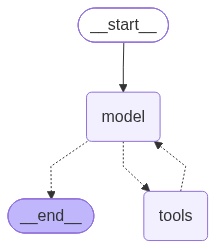

6
================================== Ai Message ==================================

结果：**84**

计算过程：12 + 30 = 42，42 × 2 = **84**。


In [25]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

@tool
def add(a: int, b: int) -> int:
    """两数相加。"""
    return a + b

@tool
def mul(a: int, b: int) -> int:
    """两数相乘。"""
    return a * b

tools = [add, mul]
bound = model.bind_tools(tools)

def agent(state: MessagesState) -> dict:
    return {"messages": [bound.invoke(state["messages"])]}

def should_continue(state: MessagesState) -> str:
    return "tools" if state["messages"][-1].tool_calls else END

# 作答

from langchain.agents import create_agent

app = create_agent(model, tools=[add, mul])

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
# 注意llm节点的名称是model

result = app.invoke({"messages": [HumanMessage("先算 12 加 30，再把结果乘以 2。")]})

print(len(result["messages"]))
result["messages"][-1].pretty_print()
#评阅
# 第 1、3 步做了，图也确实跑出 6 条消息；但第 2、4 步没做全，而它们恰是本题的关键那步：
# 题目要的是 app.get_graph().nodes.keys()，你画了 mermaid 图，然后在注释里写「llm 节点的名称是 model」——
# 结论猜对了，但没有用代码验证，也没做第 4 步的手写版对照。实测两边是：
#   预置  create_agent(model, [add, mul])               → ['__end__', '__start__', 'model', 'tools']
#   手写  agent + ToolNode + tools_condition            → ['__end__', '__start__', 'agent', 'tools']
# 差异就是模型节点叫 model 还是 agent。这不是称呼问题：interrupt_before / interrupt_after / update_state 的
# as_node 都按节点名匹配，名字写错会静默失效。所以建完图先 nodes.keys() 看一眼是好习惯。

#参考答案
# from langchain.agents import create_agent
# app_pre = create_agent(model, [add, mul])
# print(sorted(app_pre.get_graph().nodes.keys()))     # ['__end__', '__start__', 'model', 'tools']
#
# from langgraph.prebuilt import ToolNode, tools_condition
# g = StateGraph(MessagesState)
# g.add_node("agent", agent)
# g.add_node("tools", ToolNode(tools))
# g.add_edge(START, "agent")
# g.add_conditional_edges("agent", tools_condition)
# g.add_edge("tools", "agent")
# print(sorted(g.compile().get_graph().nodes.keys()))  # ['__end__', '__start__', 'agent', 'tools']




## 5. 综合：预置图照样接 checkpointer、system prompt、断点

预置只是接线，前面几个阶段的机制一个不少。

已有 `model`、工具 `add`。

1. `from langgraph.checkpoint.memory import MemorySaver`，建 `app = create_agent(model, [add], system_prompt="回答一律用中文，不超过 15 个字。", checkpointer=MemorySaver())`
2. 用同一个 `thread_id`（比如 `"pb-1"`）跑两轮：先 `HumanMessage("我叫小明。")`，再 **只传** `HumanMessage("3 加 4 是多少？")`。打印每轮返回的消息条数和最后一条 `content`
3. 再建 `app2 = create_agent(model, [add], checkpointer=MemorySaver(), interrupt_before=["tools"])`，在 `"pb-2"` 上 `invoke({"messages": [HumanMessage("3 加 4 是多少？")]}, config2)`，打印 `list(result.keys())` 和 `app2.get_state(config2).next`
4. `app2.invoke(None, config2)` 续跑，打印消息条数和最后一条 `content`

第 2 步第二轮的消息条数应该明显多（历史是 checkpointer 补的，第 3 阶段那套原封不动）。第 3 步注意 `interrupt_before` 里写的节点名——对照上一题第 5 步的答案。


In [ ]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain.agents import create_agent

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

@tool
def add(a: int, b: int) -> int:
    """两数相加。"""
    return a + b

# 作答

from langgraph.checkpoint.memory import MemorySaver

app = create_agent(
    model,
    tools = [add],
    system_prompt = "回答一律用中文，不超过 15 个字。",
    checkpointer = MemorySaver()
)

thread_config = {
    "configurable": {
        "thread_id": "pb-1"
    }
}

result = app.invoke({"messages": [HumanMessage("我叫小明。")]}, thread_config)

print(len(result["messages"]))
result["messages"][-1].pretty_print()

result = app.invoke({"messages": [HumanMessage("3 加 4 是多少？")]}, thread_config)

print(len(result["messages"]))
result["messages"][-1].pretty_print()


app2 = create_agent(
    model,
    tools = [add],
    checkpointer = MemorySaver(),
    interrupt_before = ["tools"]
)

thread_config2 = {
    "configurable": {
        "thread_id": "pb-2"
    }
}

result = app2.invoke({"messages": [HumanMessage("3 加 4 是多少？")]}, thread_config2)

print(list(result.keys()))
print(app2.get_state(thread_config2).next)


result = app2.invoke(None, thread_config2)

print(len(result["messages"]))
result["messages"][-1].pretty_print()
#评阅
# 结论都对：第二轮 6 条（历史是 checkpointer 补的）、system_prompt 生效（"你好，小明。"、"7" 都在 15 字内）、
# 断点 keys ['messages'] / next ('tools',)、续跑 4 条。但有一处要改：
#
#   thread_config = {"thread_id": "pb-1"}      # ← 少了 configurable 这一层
#
# 它这次居然能跑、历史也真的接上了，是因为 ensure_config 会把「顶层不认识、又不是 None 的键」塞进 configurable：
#   for k, v in config.items():
#       if k not in CONFIG_KEYS and v is not None:
#           empty["configurable"][k] = v
# 于是 {"thread_id": ...} 被悄悄翻成了 {"configurable": {"thread_id": ...}}。
# 但这条捷径只在走 ensure_config 的入口（invoke / stream）成立；get_state 直接读 config["configurable"]，
# 用你这个形状会抛 KeyError: 'configurable'。你下面 thread_config2 写对了，把上面也统一成
# {"configurable": {"thread_id": "pb-1"}}，别依赖这个隐式转换。

#参考答案
# cfg = {"configurable": {"thread_id": "pb-1"}}
# r1 = app.invoke({"messages": [HumanMessage("我叫小明。")]}, cfg)
# print(len(r1["messages"]), r1["messages"][-1].content)      # 2 ...
# r2 = app.invoke({"messages": [HumanMessage("3 加 4 是多少？")]}, cfg)
# print(len(r2["messages"]), r2["messages"][-1].content)      # 6 ...
#
# cfg2 = {"configurable": {"thread_id": "pb-2"}}
# r = app2.invoke({"messages": [HumanMessage("3 加 4 是多少？")]}, cfg2)
# print(list(r.keys()), app2.get_state(cfg2).next)            # ['messages'] ('tools',)
# r = app2.invoke(None, cfg2)
# print(len(r["messages"]))                                  # 4




2
================================== Ai Message ==================================

你好，小明！有什么可以帮你？
6
================================== Ai Message ==================================

3 加 4 等于 7。
['messages']
('tools',)
2
================================== Ai Message ==================================
Tool Calls:
  add (call_00_w7tzOzqJPQ7A1uO9k9Tq5517)
 Call ID: call_00_w7tzOzqJPQ7A1uO9k9Tq5517
  Args:
    a: 3
    b: 4
